# EEG_37 — Cross-Subject su Soggetti BCI-Literate

**Domanda**: i soggetti con alta accuracy subject-specific (EEG_13b) condividono
un codice neurale semantico cross-subject?

**Setup**: identici a EEG_35 baseline_dhslp, ma `SUBJ_TRAIN` filtrato ai soggetti
con test_bACC > GOOD_THRESHOLD in EEG_13b. Se buoni → buoni anche cross-subject,
il training concentrato su segnali "puliti" dovrebbe migliorare la generalizzazione.

**Atteso onesto**: 26-29%. Se esce 30%+ sarebbe un finding pubblicabile.

In [1]:
# ====================== §0 — Config ======================
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm

try:
    import wandb; _HAS_WANDB = True
except Exception:
    _HAS_WANDB = False

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg37')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents)
                     if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_CHANNELS = 61; N_SAMPLES = 384; N_CLASSES = 4
CLUSTER_SCHEME = 'concr4'; DATA_METRIC = 'abs_pcc'

# Split originale — VAL e TEST invariati per confronto equo con EEG_35
SUBJ_TRAIN_ALL = list(range(0, 50))
SUBJ_VAL       = list(range(50, 60))
SUBJ_TEST      = list(range(60, 74))

# Soglia subject-specific per definire "buono"
GOOD_THRESHOLD = 0.27   # > chance + 2%; abbassa a 0.255 per includere più soggetti

# Architettura identica a EEG_35 baseline_dhslp
K_WINDOWS=8; T_WIN=N_SAMPLES//K_WINDOWS; N_EDGES=16; D_MODEL=64; D_ENC=128; N_LAYERS=2
DROPOUT=0.4; DROPEDGE=0.10; LR=1e-3; WEIGHT_DECAY=1e-3; BATCH_SIZE=64
MAX_EPOCHS=60; PATIENCE=12; WARMUP_EPOCHS=5; LABEL_SMOOTHING=0.1
SEEDS=[42, 123, 7]

WANDB_ENTITY='uras-daniele22-politecnico-di-milano'
WANDB_PROJECT='miralis-imagined-speech'
USE_WANDB=_HAS_WANDB

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}
HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
DATA_AVAILABLE = HG_ROOT.exists() and any(HG_ROOT.rglob('trial_*.pt'))
log.info(f'device={device}  DATA_AVAILABLE={DATA_AVAILABLE}')


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
20:48:38 INFO     device=cuda  DATA_AVAILABLE=True


## §1 — Identifica soggetti BCI-Literate da checkpoints EEG_13b

In [2]:
# ====================== §1.1 — Carica test_bacc per soggetto da EEG_13b ======================
CKPT_DIR_13B = project_root / 'models' / 'eeg13b'

subj_bacc = {}
if CKPT_DIR_13B.exists():
    for f in sorted(CKPT_DIR_13B.glob('P*.pt')):
        sid = int(f.stem[1:])
        try:
            ckpt = torch.load(f, weights_only=False)
            subj_bacc[sid] = float(ckpt.get('test_bacc', 0.0))
        except Exception as e:
            log.warning(f'  skip {f.name}: {e}')
    log.info(f'Checkpoints EEG_13b caricati: {len(subj_bacc)} soggetti')
else:
    log.warning('models/eeg13b non trovata — uso fallback top-10 noti')
    # Fallback: top-10 da EEG_13b (da log sessione)
    subj_bacc = {
        68:0.3636, 15:0.3474, 26:0.3262, 1:0.3195, 51:0.3172,
        7:0.3168,  65:0.3122, 38:0.3057, 53:0.3041, 47:0.3021,
    }

# Seleziona buoni nel train split
SUBJ_TRAIN_GOOD = sorted([s for s in SUBJ_TRAIN_ALL
                           if subj_bacc.get(s, 0.0) > GOOD_THRESHOLD])

log.info(f'\nSOGLIA: {GOOD_THRESHOLD:.3f}')
log.info(f'Soggetti buoni in TRAIN ({len(SUBJ_TRAIN_GOOD)}/{len(SUBJ_TRAIN_ALL)}): {SUBJ_TRAIN_GOOD}')
log.info(f'Loro bACC S-Spec: {[round(subj_bacc.get(s,0),3) for s in SUBJ_TRAIN_GOOD]}')
log.info(f'VAL: {len(SUBJ_VAL)} soggetti (invariato)')
log.info(f'TEST: {len(SUBJ_TEST)} soggetti (invariato)')

if len(SUBJ_TRAIN_GOOD) < 3:
    log.warning('Troppo pochi soggetti buoni! Abbassa GOOD_THRESHOLD.')


20:48:38 INFO     Checkpoints EEG_13b caricati: 73 soggetti
20:48:38 INFO     
SOGLIA: 0.270
20:48:38 INFO     Soggetti buoni in TRAIN (15/50): [1, 4, 7, 8, 9, 20, 21, 22, 24, 31, 33, 36, 42, 47, 48]
20:48:38 INFO     Loro bACC S-Spec: [0.275, 0.276, 0.306, 0.279, 0.306, 0.3, 0.276, 0.286, 0.317, 0.286, 0.317, 0.281, 0.273, 0.341, 0.277]
20:48:38 INFO     VAL: 10 soggetti (invariato)
20:48:38 INFO     TEST: 14 soggetti (invariato)


## §2 — Dataset, Architettura, Training (identici a EEG_35)

In [3]:
# ====================== §2.1 — Dataset ======================
class EEGDataset(Dataset):
    def __init__(self, subj_ids, metric=DATA_METRIC):
        root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
        self.paths, self.labels = [], []
        for p in sorted(root.rglob('trial_*.pt')):
            m = _PAT.match(p.parent.name)
            if not m: continue
            sid = int(m.group(1))
            if sid not in subj_ids: continue
            d = torch.load(p, weights_only=False)
            yw = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(yw)
            if c is None: continue
            self.paths.append(p); self.labels.append(c)
        log.info(f'  {len(self.paths)} trial | {len(subj_ids)} soggetti')
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        d = torch.load(self.paths[idx], weights_only=False)
        x = d['x'].float()
        x = (x - x.mean(1, keepdim=True)) / (x.std(1, keepdim=True) + 1e-6)
        return x, torch.tensor(self.labels[idx], dtype=torch.long)

def make_loaders(subj_train):
    tr = EEGDataset(subj_train); va = EEGDataset(SUBJ_VAL); te = EEGDataset(SUBJ_TEST)
    labels = np.array(tr.labels)
    counts = np.bincount(labels, minlength=N_CLASSES)
    w = torch.tensor(1.0 / np.clip(counts[labels], 1, None), dtype=torch.float)
    sampler = WeightedRandomSampler(w, len(w), replacement=True)
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(tr, BATCH_SIZE, sampler=sampler, drop_last=True, **kw),
            DataLoader(va, BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te, BATCH_SIZE, shuffle=False, **kw))


In [4]:
# ====================== §2.2 — Architettura DHSLP (identica a EEG_35 baseline) ======================
class HGNNConv(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(d, d, bias=False)
    def forward(self, x, H):
        # x: (B, N, d) | H: (B, N, E)
        Ht  = H.transpose(1, 2)                         # (B, E, N)
        agg = torch.bmm(Ht, x)                          # (B, E, d)
        D_e = H.sum(1, keepdim=True).transpose(1, 2)    # (B, E, 1) — grado iperedge
        agg = agg / (D_e + 1e-6)
        out = torch.bmm(H, agg)                         # (B, N, d)
        D_v = H.sum(2, keepdim=True)                    # (B, N, 1) — grado vertice
        out = out / (D_v + 1e-6)
        return F.relu(self.W(out))

def drop_edge(H, p, training):
    if not training or p <= 0: return H
    mask = (torch.rand_like(H) > p).float()
    H = H * mask
    return H / (H.sum(dim=2, keepdim=True) + 1e-6)

class DHSLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj    = nn.Linear(T_WIN, D_MODEL)
        self.E       = nn.Parameter(torch.randn(N_EDGES, D_MODEL) * 0.01)
        self.pos_enc = nn.Parameter(torch.randn(N_CHANNELS, D_MODEL) * 0.01)
        self.convs   = nn.ModuleList([HGNNConv(D_ENC) for _ in range(N_LAYERS)])
        self.enc_in  = nn.Linear(D_MODEL, D_ENC)
        self.bn      = nn.BatchNorm1d(D_ENC)
        self.drop    = nn.Dropout(DROPOUT)
        self.clf     = nn.Linear(D_ENC, N_CLASSES)

    def forward(self, x):
        B = x.shape[0]
        wins = x.unfold(2, T_WIN, T_WIN)          # (B, N, K, T_win)
        z_list = []
        for k in range(K_WINDOWS):
            xk = wins[:, :, k, :]                 # (B, N, T_win)
            fk = self.proj(xk) + self.pos_enc     # (B, N, D_MODEL)
            sim = torch.bmm(fk, self.E.unsqueeze(0).expand(B,-1,-1).transpose(1,2)) / (D_MODEL**0.5)
            H   = torch.softmax(sim, dim=2)        # (B, N, E)
            H   = drop_edge(H, DROPEDGE, self.training)
            h   = self.enc_in(fk)
            for conv in self.convs:
                h = conv(h, H)
            z_list.append(h.mean(1))               # (B, D_ENC)
        z = torch.stack(z_list, 1).mean(1)         # (B, D_ENC)
        z = self.drop(F.relu(self.bn(z)))
        return self.clf(z), z


In [5]:
# ====================== §2.3 — Training loop ======================
def set_seed(s):
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        logits, _ = model(x.to(device))
        ps.append(logits.argmax(1).cpu()); ys.append(y)
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    return balanced_accuracy_score(y, p), y, p

def grl_lambda(step, total, lam_max=0.0):
    p = step / max(total, 1)
    return lam_max * (2 / (1 + math.exp(-10 * p)) - 1)

def train_model(name, subj_train, seed, run=None):
    set_seed(seed)
    tr_loader, va_loader, te_loader = make_loaders(subj_train)
    model = DHSLP().to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    ce    = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    total_steps = MAX_EPOCHS * max(len(tr_loader), 1)
    def lr_at(step):
        ep = step / max(len(tr_loader), 1)
        if ep < WARMUP_EPOCHS: return ep / max(WARMUP_EPOCHS, 1e-9)
        prog = (ep - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1e-9)
        return 0.5 * (1.0 + math.cos(math.pi * min(prog, 1.0)))
    best_va, best_state, bad, step = -1.0, None, 0, 0
    history = {'val_bacc': [], 'loss': []}
    for epoch in range(MAX_EPOCHS):
        model.train(); agg = 0; nb = 0
        for x, y in tr_loader:
            x, y = x.to(device), y.to(device)
            for g in opt.param_groups: g['lr'] = LR * lr_at(step)
            logits, _ = model(x)
            loss = ce(logits, y)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            agg += loss.item(); nb += 1; step += 1
        va_bacc, _, _ = evaluate(model, va_loader)
        if run: run.log({'val/bacc': va_bacc, 'train/loss': agg/max(nb,1), 'epoch': epoch})
        if va_bacc > best_va:
            best_va, best_state, bad = va_bacc, {k:v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            bad += 1
        history['val_bacc'].append(va_bacc)
        history['loss'].append(agg / max(nb, 1))
        log.info(f'[{name} s{seed}] ep{epoch:02d} val={va_bacc:.4f} (best={best_va:.4f}) loss={agg/max(nb,1):.3f}')
        if bad >= PATIENCE:
            log.info(f'[{name} s{seed}] early stop @ep{epoch}'); break
    if best_state: model.load_state_dict(best_state)
    te_bacc, y_te, p_te = evaluate(model, te_loader)
    log.info(f'[{name} s{seed}] >>> val={best_va:.4f}  test={te_bacc:.4f}')
    return dict(val_bacc=best_va, test_bacc=te_bacc, y_te=y_te, p_te=p_te, history=history)


## §3 — Esperimento: good-only vs all-subjects

In [6]:
# ====================== §3.1 — Esegui: good vs all ======================
CONFIGS = [
    ('good_only',   SUBJ_TRAIN_GOOD),   # solo buoni
    ('all_subjects', SUBJ_TRAIN_ALL),   # baseline EEG_35 (riferimento)
]

results = {}
if DATA_AVAILABLE:
    for (name, subj_train) in CONFIGS:
        log.info(f'\n=== {name} ({len(subj_train)} soggetti train) ===')
        seed_res = []
        for seed in SEEDS:
            run = None
            if USE_WANDB:
                try:
                    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                                     name=f'eeg37_{name}_{CLUSTER_SCHEME}_s{seed}',
                                     group='eeg37_good_subjects',
                                     config=dict(notebook='EEG_37', config=name,
                                                 n_train_subj=len(subj_train),
                                                 good_threshold=GOOD_THRESHOLD,
                                                 n_classes=N_CLASSES, lr=LR,
                                                 batch_size=BATCH_SIZE, seed=seed),
                                     reinit='finish_previous')
                except Exception as e:
                    log.warning(f'W&B: {e}'); run = None
            r = train_model(name, subj_train, seed, run=run)
            if run:
                run.summary['val_bacc']  = r['val_bacc']
                run.summary['test_bacc'] = r['test_bacc']
                run.finish()
            seed_res.append(r)
        results[name] = seed_res
        vb = np.array([r['val_bacc'] for r in seed_res])
        tb = np.array([r['test_bacc'] for r in seed_res])
        log.info(f'=== {name}: val {vb.mean():.4f}±{vb.std():.4f} | test {tb.mean():.4f}±{tb.std():.4f} ===')
else:
    log.warning('Dati non disponibili. Esegui sul server.')


20:48:38 INFO     
=== good_only (15 soggetti train) ===
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


20:48:46 INFO       7807 trial | 15 soggetti
20:48:50 INFO       5500 trial | 10 soggetti
20:48:56 INFO       7260 trial | 14 soggetti
20:49:01 INFO     [good_only s42] ep00 val=0.2554 (best=0.2554) loss=1.404
20:49:04 INFO     [good_only s42] ep01 val=0.2470 (best=0.2554) loss=1.388
20:49:07 INFO     [good_only s42] ep02 val=0.2476 (best=0.2554) loss=1.386
20:49:10 INFO     [good_only s42] ep03 val=0.2472 (best=0.2554) loss=1.384
20:49:13 INFO     [good_only s42] ep04 val=0.2495 (best=0.2554) loss=1.385
20:49:16 INFO     [good_only s42] ep05 val=0.2544 (best=0.2554) loss=1.385
20:49:20 INFO     [good_only s42] ep06 val=0.2495 (best=0.2554) loss=1.382
20:49:23 INFO     [good_only s42] ep07 val=0.2558 (best=0.2558) loss=1.382
20:49:26 INFO     [good_only s42] ep08 val=0.2487 (best=0.2558) loss=1.377
20:49:29 INFO     [good_only s42] ep09 val=0.2507 (best=0.2558) loss=1.379
20:49:32 INFO     [good_only s42] ep10 val=0.2483 (best=0.2558) loss=1.377
20:49:35 INFO     [good_only s42] ep11 v

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/loss,█▇▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▄▃▃▂▂▁
val/bacc,▆▃▃▃▄▆▄▇▄▅▄▃▄▃▇▆▆▃▄▆▄▂█▅█▁▅▅▇▃▂▃▄▇▅
epoch,34
test_bacc,0.25229
train/loss,1.308
val/bacc,0.25166
val_bacc,0.25938


20:50:51 INFO       7807 trial | 15 soggetti
20:50:53 INFO       5500 trial | 10 soggetti
20:50:54 INFO       7260 trial | 14 soggetti
20:50:57 INFO     [good_only s123] ep00 val=0.2546 (best=0.2546) loss=1.403
20:51:00 INFO     [good_only s123] ep01 val=0.2510 (best=0.2546) loss=1.391
20:51:03 INFO     [good_only s123] ep02 val=0.2506 (best=0.2546) loss=1.386
20:51:06 INFO     [good_only s123] ep03 val=0.2510 (best=0.2546) loss=1.387
20:51:09 INFO     [good_only s123] ep04 val=0.2495 (best=0.2546) loss=1.383
20:51:12 INFO     [good_only s123] ep05 val=0.2501 (best=0.2546) loss=1.386
20:51:15 INFO     [good_only s123] ep06 val=0.2496 (best=0.2546) loss=1.381
20:51:18 INFO     [good_only s123] ep07 val=0.2564 (best=0.2564) loss=1.380
20:51:21 INFO     [good_only s123] ep08 val=0.2491 (best=0.2564) loss=1.381
20:51:24 INFO     [good_only s123] ep09 val=0.2602 (best=0.2602) loss=1.379
20:51:27 INFO     [good_only s123] ep10 val=0.2504 (best=0.2602) loss=1.376
20:51:30 INFO     [good_only 

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
train/loss,█▆▅▅▅▅▄▄▄▄▃▄▃▃▂▃▂▂▂▂▁▁
val/bacc,▆▄▄▄▃▄▃▆▃█▄▁▃▅▃▄▅▄▄▄▄▁
epoch,21
test_bacc,0.25105
train/loss,1.36314
val/bacc,0.24445
val_bacc,0.26024


...

20:57:42 INFO       26123 trial | 50 soggetti
20:57:43 INFO       5500 trial | 10 soggetti
20:57:45 INFO       7260 trial | 14 soggetti
20:57:52 INFO     [all_subjects s123] ep00 val=0.2456 (best=0.2456) loss=1.401
20:57:59 INFO     [all_subjects s123] ep01 val=0.2518 (best=0.2518) loss=1.391
20:58:07 INFO     [all_subjects s123] ep02 val=0.2541 (best=0.2541) loss=1.388
20:58:15 INFO     [all_subjects s123] ep03 val=0.2518 (best=0.2541) loss=1.388
20:58:22 INFO     [all_subjects s123] ep04 val=0.2441 (best=0.2541) loss=1.387
20:58:30 INFO     [all_subjects s123] ep05 val=0.2495 (best=0.2541) loss=1.387
20:58:37 INFO     [all_subjects s123] ep06 val=0.2506 (best=0.2541) loss=1.387
20:58:45 INFO     [all_subjects s123] ep07 val=0.2496 (best=0.2541) loss=1.387
20:58:53 INFO     [all_subjects s123] ep08 val=0.2485 (best=0.2541) loss=1.386
20:59:01 INFO     [all_subjects s123] ep09 val=0.2431 (best=0.2541) loss=1.387
20:59:09 INFO     [all_subjects s123] ep10 val=0.2505 (best=0.2541) loss=1

epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train/loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁
val/bacc,▂▆▇▆▂▄▅▄▄▁▅▅▂▅█▅▅▆▅▇▇▃▆▃▂▆▅
epoch,26
test_bacc,0.2549
train/loss,1.3837
val/bacc,0.25053
val_bacc,0.25608


21:01:21 INFO       26123 trial | 50 soggetti
21:01:22 INFO       5500 trial | 10 soggetti
21:01:23 INFO       7260 trial | 14 soggetti
21:01:31 INFO     [all_subjects s7] ep00 val=0.2474 (best=0.2474) loss=1.398
21:01:38 INFO     [all_subjects s7] ep01 val=0.2491 (best=0.2491) loss=1.389
21:01:46 INFO     [all_subjects s7] ep02 val=0.2524 (best=0.2524) loss=1.388
21:01:54 INFO     [all_subjects s7] ep03 val=0.2486 (best=0.2524) loss=1.388
21:02:02 INFO     [all_subjects s7] ep04 val=0.2556 (best=0.2556) loss=1.386
21:02:09 INFO     [all_subjects s7] ep05 val=0.2493 (best=0.2556) loss=1.387
21:02:17 INFO     [all_subjects s7] ep06 val=0.2477 (best=0.2556) loss=1.387
21:02:24 INFO     [all_subjects s7] ep07 val=0.2450 (best=0.2556) loss=1.387
21:02:32 INFO     [all_subjects s7] ep08 val=0.2478 (best=0.2556) loss=1.387
21:02:39 INFO     [all_subjects s7] ep09 val=0.2601 (best=0.2601) loss=1.386
21:02:47 INFO     [all_subjects s7] ep10 val=0.2474 (best=0.2601) loss=1.387
21:02:54 INFO    

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
train/loss,█▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val/bacc,▄▄▅▄▇▄▄▃▄█▄▁▅▅▆▅▃▅▄▄▅▅
epoch,21
test_bacc,0.24379
train/loss,1.38515
val/bacc,0.25158
val_bacc,0.26008


21:04:14 INFO     === all_subjects: val 0.2582±0.0016 | test 0.2502±0.0047 ===


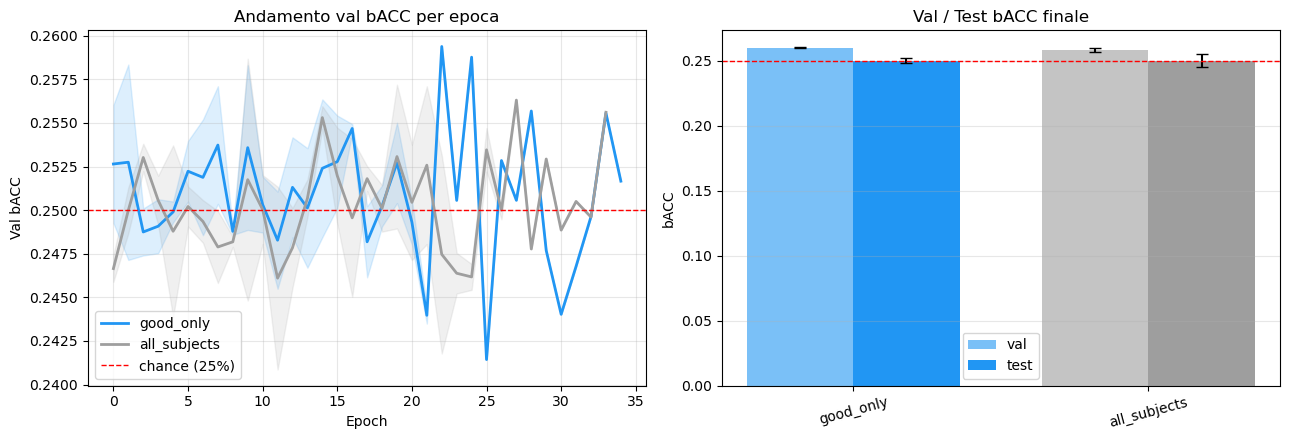

Salvato in figures/eeg37_results.png


In [7]:
# ====================== §3.2 — Plot andamento (se results in memoria) ======================
if 'results' in dir() and results:
    import matplotlib.pyplot as plt
    import numpy as np

    COLORS = {'good_only': '#2196F3', 'all_subjects': '#9E9E9E'}
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # --- sinistra: val_bacc per epoca ---
    ax = axes[0]
    for name, seed_res in results.items():
        col = COLORS.get(name, '#333')
        histories = [r['history']['val_bacc'] for r in seed_res if 'history' in r]
        if not histories:
            continue
        max_ep = max(len(h) for h in histories)
        mat = np.full((len(histories), max_ep), np.nan)
        for i, h in enumerate(histories):
            mat[i, :len(h)] = h
        mu  = np.nanmean(mat, 0)
        std = np.nanstd(mat, 0)
        ep  = np.arange(max_ep)
        ax.plot(ep, mu, color=col, lw=2, label=name)
        ax.fill_between(ep, mu-std, mu+std, color=col, alpha=0.15)
    ax.axhline(0.25, ls='--', color='red', lw=1, label='chance (25%)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val bACC')
    ax.set_title('Andamento val bACC per epoca')
    ax.legend(); ax.grid(alpha=.3)

    # --- destra: bar chart finale ---
    ax = axes[1]
    names = list(results.keys())
    x = np.arange(len(names)); w = 0.36
    vb = np.array([np.mean([r['val_bacc']  for r in results[n]]) for n in names])
    tb = np.array([np.mean([r['test_bacc'] for r in results[n]]) for n in names])
    ve = np.array([np.std([r['val_bacc']  for r in results[n]]) for n in names])
    te = np.array([np.std([r['test_bacc'] for r in results[n]]) for n in names])
    ax.bar(x - w/2, vb, w, yerr=ve, capsize=4, label='val',  color=[COLORS.get(n,'#333') for n in names], alpha=.6)
    ax.bar(x + w/2, tb, w, yerr=te, capsize=4, label='test', color=[COLORS.get(n,'#333') for n in names])
    ax.axhline(0.25, ls='--', color='red', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('bACC'); ax.set_title('Val / Test bACC finale')
    ax.legend(); ax.grid(axis='y', alpha=.3)

    plt.tight_layout()
    plt.savefig(project_root / 'figures' / 'eeg37_results.png', dpi=150)
    plt.show()
    print("Salvato in figures/eeg37_results.png")
else:
    print("results non ancora disponibili — esegui §3.1 prima.")


## §4 — Risultati

21:04:30 INFO     Figura: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg37_good_subjects.png


      config  n_train  val_bacc  val_std  test_bacc  test_std  delta_vs_all
   good_only       15  0.259982 0.000425   0.250138  0.002227     -0.000045
all_subjects       50  0.258235 0.001649   0.250183  0.004684      0.000000


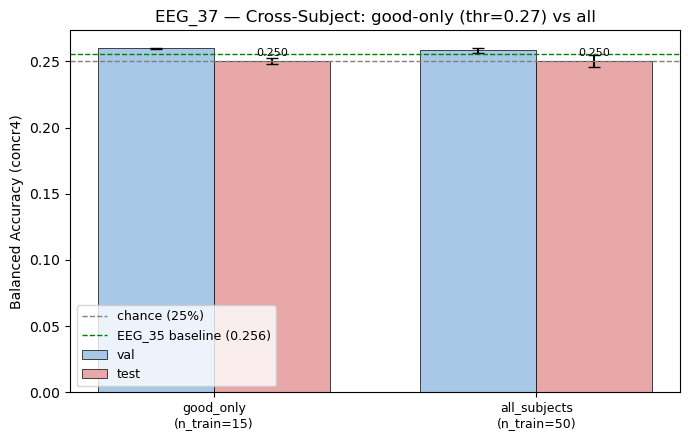

In [8]:
# ====================== §4.1 — Tabella + plot ======================
if results:
    import pandas as pd
    rows = []
    for name, seed_res in results.items():
        vb = np.array([r['val_bacc'] for r in seed_res])
        tb = np.array([r['test_bacc'] for r in seed_res])
        rows.append(dict(config=name, n_train=len(SUBJ_TRAIN_GOOD if 'good' in name else SUBJ_TRAIN_ALL),
                         val_bacc=vb.mean(), val_std=vb.std(),
                         test_bacc=tb.mean(), test_std=tb.std()))
    df = pd.DataFrame(rows)
    df['delta_vs_all'] = df['test_bacc'] - df.loc[df.config=='all_subjects','test_bacc'].values[0]
    print(df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(df)); w = 0.36
    ax.bar(x-w/2, df.val_bacc,  w, yerr=df.val_std,  capsize=4, color='#A8C8E8', label='val',  edgecolor='k', lw=.5)
    ax.bar(x+w/2, df.test_bacc, w, yerr=df.test_std, capsize=4, color='#E8A8A8', label='test', edgecolor='k', lw=.5)
    ax.axhline(0.25, ls='--', color='gray', lw=1, label='chance (25%)')
    ax.axhline(0.2556, ls='--', color='green', lw=1, label='EEG_35 baseline (0.256)')
    ax.set_xticks(x); ax.set_xticklabels(
        [f'{r.config}\n(n_train={r.n_train})' for r in df.itertuples()], fontsize=9)
    ax.set_ylabel('Balanced Accuracy (concr4)')
    ax.set_title(f'EEG_37 — Cross-Subject: good-only (thr={GOOD_THRESHOLD}) vs all')
    ax.legend(fontsize=9)
    for xi, v in zip(x, df.test_bacc): ax.text(xi+w/2, v+0.004, f'{v:.3f}', ha='center', fontsize=8)
    plt.tight_layout()
    out = FIG_DIR / 'eeg37_good_subjects.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); log.info(f'Figura: {out}')
    plt.show()


## §5 — Come leggere i risultati

| Esito | Interpretazione |
|-------|-----------------|
| `good_only` test > `all_subjects` test (+3%+) | I buoni condividono un codice cross-subject. Training concentrato su segnali puliti aiuta. |
| `good_only` ≈ `all_subjects` (< +1%) | La buona performance S-Spec è idiosincratica — ogni soggetto ha il suo codice stabile ma non trasferibile. |
| `good_only` < `all_subjects` | Meno dati di training > qualità dati: il modello soffre della scarsità di soggetti. |